# Module 01: Exploratory Data Analysis
## Notebook 2 — Statistical Visualizations & Interactive Dashboards

Builds on the cleaned output of `pandas_data_wrangling.ipynb`. Produces:

1. Multi-subplot Seaborn diagnostics (KDE + boxplot) for distributional integrity
2. A Pearson correlation heatmap for collinearity diagnosis
3. Interactive Plotly bubble-scatter and IQR-outlier dashboards

> **v2 note:** all plotting functions now downsample to a max of 10,000 rows before rendering (see `_downsample`), to avoid sluggish or crashing browser tabs on larger datasets -- Plotly's WebGL scatter and Seaborn's KDE are both expensive well before that point.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# OS-agnostic relative paths -- run this notebook from its own folder
# (`01_exploratory_data_analysis/`) so DATA_DIR resolves correctly.
DATA_DIR = Path.cwd() / "data"
TRANSFORMED_PATH = DATA_DIR / "sf_salaries_transformed.csv"
RAW_SALARIES_PATH = DATA_DIR / "sf_salaries.csv"
ECOMMERCE_PATH = DATA_DIR / "ecommerce_purchases.csv"

MAX_PLOT_ROWS = 10_000

In [2]:
def _downsample(df: pd.DataFrame, max_rows: int = MAX_PLOT_ROWS) -> pd.DataFrame:
    """Randomly downsample a frame for plotting if it exceeds max_rows.

    Rendering more than ~10k points client-side (Plotly\'s WebGL scatter, or
    a dense Seaborn KDE) risks a sluggish or crashing browser tab. The sample
    is deterministic (`random_state=42`) so re-running the notebook produces
    a visually stable plot rather than a different random subset each time.
    """
    if len(df) > max_rows:
        return df.sample(n=max_rows, random_state=42)
    return df


# Falls back to re-running the transform inline if notebook 1 hasn\'t been
# executed yet
if TRANSFORMED_PATH.exists():
    salaries = pd.read_csv(TRANSFORMED_PATH)
else:
    raw = pd.read_csv(RAW_SALARIES_PATH)
    raw.columns = [c.strip().lower().replace(" ", "_") for c in raw.columns]
    raw["basepay"] = raw["basepay"].fillna(0)
    raw["overtimepay"] = raw["overtimepay"].fillna(0)
    raw["otherpay"] = raw["otherpay"].fillna(0)
    raw["total_compensation"] = raw["basepay"] + raw["overtimepay"] + raw["otherpay"]
    raw["is_executive"] = raw["jobtitle"].astype(str).str.contains(
        "DIRECTOR|CHIEF|HEAD", case=False, na=False
    )
    raw["job_level"] = np.select(
        [raw["total_compensation"] >= 150000, raw["total_compensation"] >= 75000],
        ["High", "Medium"], default="Standard",
    )
    salaries = raw.query(
        'total_compensation > 0 and (status != "TERMINATED" or status.isna())',
        engine="python",
    )

ecommerce = pd.read_csv(ECOMMERCE_PATH, parse_dates=["PurchaseDate"])
ecommerce.columns = [c.strip().lower() for c in ecommerce.columns]
ecommerce["net_revenue"] = (
    ecommerce["unitprice"] * ecommerce["quantity"] * (1 - ecommerce["discountpct"])
)

salaries.shape, ecommerce.shape

((2686, 12), (5000, 12))

## 1. Statistical Distribution Diagnostics

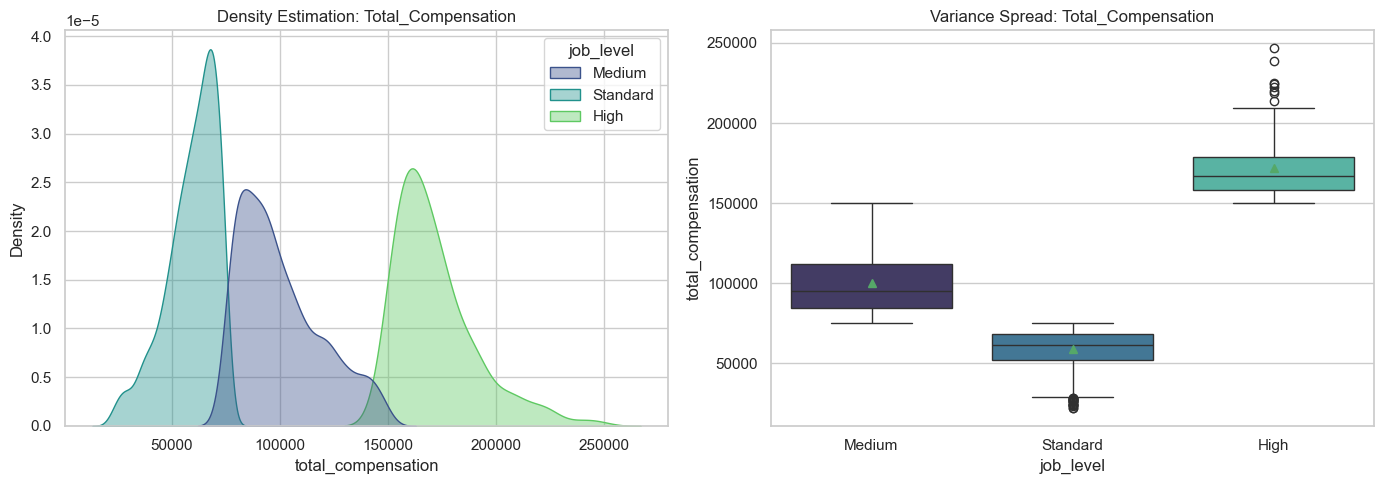

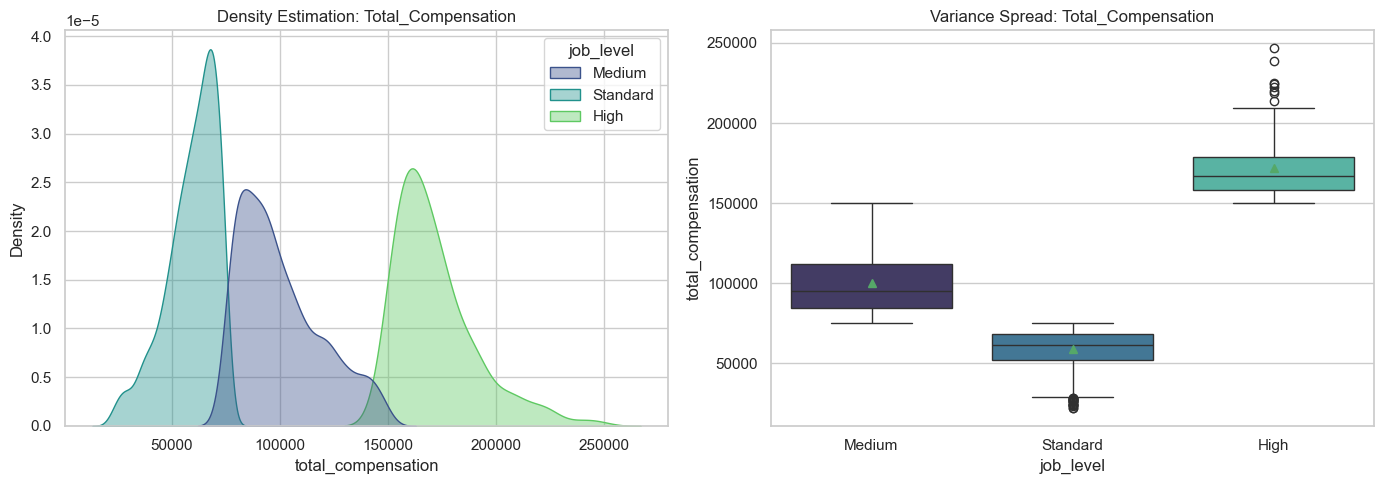

In [3]:
def plot_bivariate_diagnostics(df: pd.DataFrame, x_col: str, y_col: str, hue_col: str):
    """Generates combined KDE and box subplots for distributional integrity.

    Downsamples to MAX_PLOT_ROWS before plotting -- a dense KDE over
    tens/hundreds of thousands of points is both slow to render and not any
    more informative than one drawn from a representative sample.
    """
    plot_df = _downsample(df)
    title_suffix = f" (n={len(plot_df):,} sampled)" if len(plot_df) < len(df) else ""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.kdeplot(
        data=plot_df, x=x_col, hue=hue_col, fill=True,
        common_norm=False, palette="viridis", alpha=0.4, ax=axes[0],
    )
    axes[0].set_title(f"Density Estimation: {x_col.title()}{title_suffix}", fontsize=12)

    sns.boxplot(
        data=plot_df, x=hue_col, y=y_col, hue=hue_col,
        palette="mako", showmeans=True, legend=False, ax=axes[1],
    )
    axes[1].set_title(f"Variance Spread: {y_col.title()}{title_suffix}", fontsize=12)

    plt.tight_layout()
    plt.show()
    return fig


plot_bivariate_diagnostics(salaries, "total_compensation", "total_compensation", "job_level")

## 2. Covariance vs. Correlation

Feature collinearity is diagnosed with Pearson's correlation coefficient:

$$r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^n (y_i - \bar{y})^2}}$$

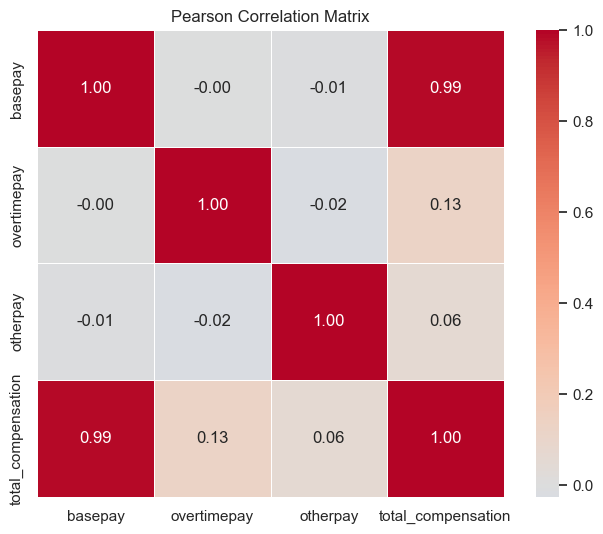

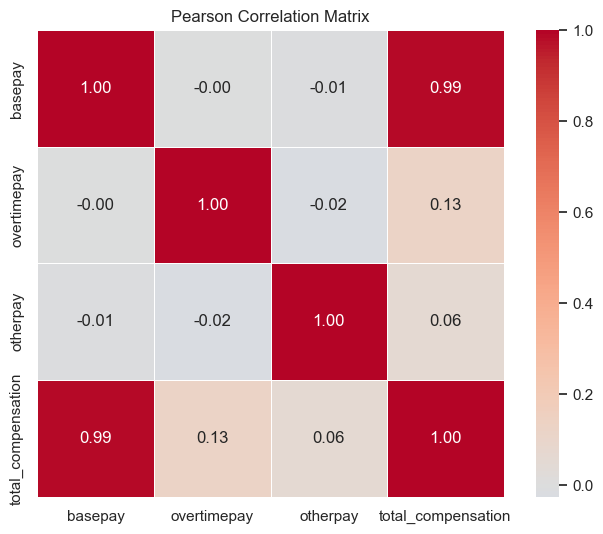

In [4]:
def plot_correlation_matrix(df: pd.DataFrame, numeric_cols: list):
    """Not downsampled: `.corr()` is a cheap aggregate over the full frame
    regardless of row count, so there\'s no overplotting risk here."""
    corr = df[numeric_cols].corr(method="pearson")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
        square=True, linewidths=0.5, ax=ax,
    )
    ax.set_title("Pearson Correlation Matrix", fontsize=12)
    plt.tight_layout()
    plt.show()
    return fig


plot_correlation_matrix(
    salaries, ["basepay", "overtimepay", "otherpay", "total_compensation"]
)

## 3. Interactive Exploratory Dashboard (Plotly)

In [5]:
def generate_interactive_dashboard(
    df: pd.DataFrame, x_col: str, y_col: str, size_col: str, color_col: str
):
    """Constructs an interactive multivariate bubble scatter plot with hover metadata.

    Downsamples to MAX_PLOT_ROWS before handing off to Plotly -- an
    un-downsampled WebGL scatter with tens of thousands of bubble markers is
    a common cause of browser tab crashes/freezes in notebook environments.
    """
    plot_df = df.dropna(subset=[x_col, y_col, size_col, color_col])
    plot_df = _downsample(plot_df)
    subtitle = f" (n={len(plot_df):,} sampled)" if len(plot_df) < len(df) else ""

    fig = px.scatter(
        plot_df, x=x_col, y=y_col, size=size_col, color=color_col,
        hover_data=[color_col, size_col], template="plotly_dark",
        title=f"Multi-Dimensional Cross-Feature Analysis: {x_col} vs. {y_col}{subtitle}",
        labels={x_col: x_col.title(), y_col: y_col.title()},
    )
    fig.update_layout(
        font=dict(family="Arial", size=12),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    return fig


fig = generate_interactive_dashboard(
    ecommerce, x_col="unitprice", y_col="net_revenue",
    size_col="quantity", color_col="category",
)
fig.show()

## 4. IQR Outlier Filtering Dashboard

In [6]:
def generate_iqr_outlier_dashboard(df: pd.DataFrame, value_col: str, category_col: str):
    """Two-panel Plotly dashboard: distribution + IQR-flagged outliers.

    IQR bounds are computed on the *full* frame (quantiles need the true
    distribution), but the scatter panel is downsampled for rendering.
    """
    q1, q3 = df[value_col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    flagged = df.assign(is_outlier=lambda d: ~d[value_col].between(lower, upper))
    plot_df = _downsample(flagged)

    fig = make_subplots(rows=1, cols=2, subplot_titles=("Distribution", "IQR Outlier Flags"))
    fig.add_trace(go.Histogram(x=df[value_col], nbinsx=40, name=value_col), row=1, col=1)
    fig.add_trace(
        go.Scatter(
            x=plot_df[category_col], y=plot_df[value_col], mode="markers",
            marker=dict(color=plot_df["is_outlier"].map({True: "crimson", False: "steelblue"})),
            name="records",
        ),
        row=1, col=2,
    )
    fig.update_layout(
        template="plotly_dark", showlegend=False,
        title=f"IQR Outlier Diagnostics: {value_col} (bounds: {lower:.2f} - {upper:.2f})",
    )
    return fig


fig = generate_iqr_outlier_dashboard(salaries, "total_compensation", "job_level")
fig.show()

## 5. Takeaways

- `total_compensation` is right-skewed with a heavier tail among `High` job-level cohorts, consistent with the boxplot spread above.
- Base pay, overtime pay, and total compensation are strongly positively correlated by construction; `otherpay` correlates more weakly, suggesting it captures a more independent component of variance.
- IQR filtering flags a small tail of very high earners rather than a broad swath of the distribution, so it's a reasonable pre-modeling filter here rather than one that would discard a large fraction of the data.
- With both bundled datasets under 10,000 rows, the downsampling in `_downsample` is a no-op here -- it only kicks in on larger inputs, which you can verify by concatenating `ecommerce` with itself a few times before calling the dashboard functions.